# CPE 342 Machine Learning - Assignment 1
## Training Models: OLS Regression

King Mongkut's University of Technology Thonburi
Faculty of Engineering, Department of Computer Engineering

**Semester 1/2024 &nbsp;&middot;&nbsp; Due: 21 August &nbsp;&middot;&nbsp; Submit report as PDF to LEB2**

| | |
|---|---|
| **Name** | &nbsp; |
| **Student ID** | &nbsp; |
| **Section** | &nbsp; |
| **Date** | &nbsp; |

---

### The problem

A small business recorded its monthly advertising expenditure and the corresponding sales
for 10 months. Two variables:

| Symbol | Variable | Unit |
|---|---|---|
| **X** | Advertising Budget | thousands of dollars (k$) |
| **Y** | Sales | thousands of units (k units) |

### Tasks, and where each one is answered

| Task | Asked for | Section |
|---|---|---|
| 1a | Fit a simple linear regression by OLS | 1a |
| 1b | Compute the regression coefficients (intercept and slope) | 1b |
| 1c | Write down the equation of the fitted line | 1c |
| 2a | Interpret the slope and intercept in context | 2a |
| 2b | Predict sales when the advertising budget is $12,000 | 2b |
| 3a | Calculate R-squared | 3a |
| 3b | Interpret the R-squared value | 3b |

### How to read this notebook

Every task follows the same three beats:

1. **Method** - what is being computed and why, with the mathematics written out.
2. **Code** - the computation, printing every intermediate number so it can be checked by hand.
3. **Your explanation** - a blank slot for you to write in, with a collapsible list of the
   relevant numbers underneath so you never have to scroll back to find them.

**A note on units.** Every number is reported in *model-native units* (thousands), with the
plain real-world count in parentheses on first mention - for example
"16.93 thousand units (about 16,933 units)". A bare number with no unit is the easiest way
to lose marks on this assignment.

**Environment.** Kernel `CPE342 (.venv)`, Python 3.14, packages pinned in `requirements.txt`
at the repository root.

---

## 0. Setup and data

The dataset is small enough to transcribe directly from the assignment sheet, so it lives
inline in the notebook rather than in a separate file - the grader can then see the exact
data the model was fitted to.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.precision", 4)

# Data transcribed from the assignment sheet (10 months).
data = {
    "month":        [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "budget_kusd":  [3.0, 5.0, 2.0, 7.0, 8.0, 1.0, 4.0, 6.0, 9.0, 10.0],   # X, thousands of dollars
    "sales_kunits": [6.0, 9.0, 4.0, 10.0, 12.0, 3.0, 7.0, 8.0, 13.0, 15.0],  # Y, thousands of units
}
df = pd.DataFrame(data).set_index("month")

x = df["budget_kusd"].to_numpy(dtype=float)   # predictor X
y = df["sales_kunits"].to_numpy(dtype=float)  # response  Y
n = len(x)

print(f"n = {n} observations")
print(f"X ranges from {x.min():g} to {x.max():g} (thousand dollars)")
print(f"Y ranges from {y.min():g} to {y.max():g} (thousand units)")
df

n = 10 observations
X ranges from 1 to 10 (thousand dollars)
Y ranges from 3 to 15 (thousand units)


,budget_kusd,sales_kunits
month,,
1,3.0,6.0
2,5.0,9.0
3,2.0,4.0
4,7.0,10.0
5,8.0,12.0
6,1.0,3.0
7,4.0,7.0
8,6.0,8.0
9,9.0,13.0


---

# Task 1 - Implement OLS Regression

## 1a. Fitting a simple linear regression by OLS

### The model

For each month $i$ the model assumes

$$y_i = \beta_0 + \beta_1 x_i + \varepsilon_i , \qquad i = 1,\dots,n$$

where $\beta_0$ is the **intercept**, $\beta_1$ is the **slope**, and $\varepsilon_i$ is the
part of $y_i$ the straight line cannot account for.

### The criterion

**Ordinary Least Squares** does not add any assumption to the model - it is a rule for
*choosing* $\beta_0$ and $\beta_1$: pick the pair that minimises the sum of squared residuals,

$$\mathrm{SSE}(\beta_0, \beta_1) \;=\; \sum_{i=1}^{n} \bigl(y_i - \beta_0 - \beta_1 x_i\bigr)^2 .$$

Squaring does two jobs: it stops positive and negative misses from cancelling, and it makes the
criterion differentiable - which is what lets us solve it exactly instead of searching for the
answer.

### Derivation 1 - the scalar route

$\mathrm{SSE}$ is a smooth convex function of two variables, so its minimum sits where both
partial derivatives vanish:

$$\frac{\partial \mathrm{SSE}}{\partial \beta_0}
= -2 \sum_{i=1}^{n} \bigl(y_i - \beta_0 - \beta_1 x_i\bigr) = 0$$

$$\frac{\partial \mathrm{SSE}}{\partial \beta_1}
= -2 \sum_{i=1}^{n} x_i \bigl(y_i - \beta_0 - \beta_1 x_i\bigr) = 0$$

Dropping the $-2$ and rearranging gives the two **normal equations**:

$$n\,\beta_0 \;+\; \beta_1 \sum x_i \;=\; \sum y_i$$

$$\beta_0 \sum x_i \;+\; \beta_1 \sum x_i^2 \;=\; \sum x_i y_i$$

Two linear equations in two unknowns. Solving them:

$$\boxed{\;\beta_1 = \frac{n\sum x_i y_i - \sum x_i \sum y_i}{n \sum x_i^2 - \left(\sum x_i\right)^2}\;}
\qquad
\boxed{\;\beta_0 = \bar{y} - \beta_1 \bar{x}\;}$$

The second formula says something worth remembering: the fitted line always passes through the
centroid $(\bar{x}, \bar{y})$ of the data.

### Derivation 2 - the matrix route

Stack the data. Let $\mathbf{X}$ be the $n \times 2$ **design matrix** whose first column is all
ones - that column is what gives the model an intercept - and whose second column is $x$:

$$\mathbf{X} = \begin{bmatrix} 1 & x_1 \\ 1 & x_2 \\ \vdots & \vdots \\ 1 & x_n \end{bmatrix},
\qquad
\boldsymbol{\beta} = \begin{bmatrix} \beta_0 \\ \beta_1 \end{bmatrix},
\qquad
\mathbf{y} = \begin{bmatrix} y_1 \\ \vdots \\ y_n \end{bmatrix}$$

The same criterion is then a squared vector norm:

$$\mathrm{SSE}(\boldsymbol{\beta}) = \lVert \mathbf{y} - \mathbf{X}\boldsymbol{\beta} \rVert^2
= \mathbf{y}^\top\mathbf{y} - 2\boldsymbol{\beta}^\top \mathbf{X}^\top \mathbf{y}
+ \boldsymbol{\beta}^\top \mathbf{X}^\top \mathbf{X} \boldsymbol{\beta}$$

Differentiating with respect to the whole vector and setting it to zero:

$$\frac{\partial \mathrm{SSE}}{\partial \boldsymbol{\beta}}
= -2\mathbf{X}^\top \mathbf{y} + 2\mathbf{X}^\top \mathbf{X} \boldsymbol{\beta} = \mathbf{0}
\quad\Longrightarrow\quad
\mathbf{X}^\top \mathbf{X} \boldsymbol{\beta} = \mathbf{X}^\top \mathbf{y}
\quad\Longrightarrow\quad
\boxed{\;\boldsymbol{\beta} = \left(\mathbf{X}^\top \mathbf{X}\right)^{-1} \mathbf{X}^\top \mathbf{y}\;}$$

### The two derivations are the same thing

Write out the matrix products for this design matrix:

$$\mathbf{X}^\top \mathbf{X} = \begin{bmatrix} n & \sum x_i \\ \sum x_i & \sum x_i^2 \end{bmatrix},
\qquad
\mathbf{X}^\top \mathbf{y} = \begin{bmatrix} \sum y_i \\ \sum x_i y_i \end{bmatrix}$$

So $\mathbf{X}^\top \mathbf{X} \boldsymbol{\beta} = \mathbf{X}^\top \mathbf{y}$ *is*, entry by
entry, the two normal equations from the scalar route. The matrix form is not a second method -
it is the same method written so that it also works for 2, 10 or 100 predictors, which is why
every later lab uses it. (It is also the form used in the course notebook
`material/ML_2_Training_Models.ipynb`.)

$\mathbf{X}^\top \mathbf{X}$ is invertible as long as $x$ is not constant, and in that case it is
positive definite - which confirms the stationary point is a **minimum**, not a maximum or a
saddle point.

### The sums we need

Both routes need the same five numbers: $n$, $\sum x_i$, $\sum y_i$, $\sum x_i y_i$ and
$\sum x_i^2$. The cell below builds them as a worksheet that can be checked on a calculator.

In [2]:
# Worksheet: every quantity the normal equations need, row by row.
work = pd.DataFrame({
    "x (budget, k$)": x,
    "y (sales, k units)": y,
    "x*y": x * y,
    "x^2": x ** 2,
}, index=df.index)

totals = work.sum()
totals.name = "SUM"
work_display = pd.concat([work, totals.to_frame().T])

sum_x, sum_y = x.sum(), y.sum()
sum_xy, sum_xx = (x * y).sum(), (x ** 2).sum()
x_bar, y_bar = x.mean(), y.mean()

print(f"n        = {n}")
print(f"sum x    = {sum_x:g}")
print(f"sum y    = {sum_y:g}")
print(f"sum xy   = {sum_xy:g}")
print(f"sum x^2  = {sum_xx:g}")
print(f"x_bar    = {x_bar:g}  (thousand dollars)")
print(f"y_bar    = {y_bar:g}  (thousand units)")
work_display

n        = 10
sum x    = 55
sum y    = 87
sum xy   = 583
sum x^2  = 385
x_bar    = 5.5  (thousand dollars)
y_bar    = 8.7  (thousand units)


,"x (budget, k$)","y (sales, k units)",x*y,x^2
1,3.0,6.0,18.0,9.0
2,5.0,9.0,45.0,25.0
3,2.0,4.0,8.0,4.0
4,7.0,10.0,70.0,49.0
5,8.0,12.0,96.0,64.0
6,1.0,3.0,3.0,1.0
7,4.0,7.0,28.0,16.0
8,6.0,8.0,48.0,36.0
9,9.0,13.0,117.0,81.0
10,10.0,15.0,150.0,100.0


### Your explanation - 1a - the OLS method

> _Write your answer here._

<details>
<summary>Raw material (click to expand) - numbers and points you may want to cite</summary>

- OLS chooses the coefficients that minimise SSE = sum of (y_i - beta_0 - beta_1*x_i)^2.
- Squaring prevents positive and negative residuals from cancelling, and keeps the criterion differentiable.
- Setting both partial derivatives to zero gives the two normal equations - hence a *closed-form* solution, with no iteration needed.
- The five sums for this dataset: n = 10, sum x = 55, sum y = 87, sum xy = 583, sum x^2 = 385.
- Means: x_bar = 5.5 thousand dollars, y_bar = 8.7 thousand units. The fitted line must pass through this point.
- The scalar and matrix derivations produce the identical system; the matrix form is the one that generalises to many predictors.

</details>

## 1b. Computing the regression coefficients

The same fit, computed three ways. The first two are the two derivations above; the third is an
independent library implementation used purely as a check. If all three agree, the arithmetic is
verified rather than merely asserted.

**Method 1 - the closed-form scalar formulas.**

In [3]:
# Method 1: closed-form scalar formulas.
beta1_scalar = (n * sum_xy - sum_x * sum_y) / (n * sum_xx - sum_x ** 2)
beta0_scalar = y_bar - beta1_scalar * x_bar

print("Numerator   n*sum_xy - sum_x*sum_y = "
      f"{n}*{sum_xy:g} - {sum_x:g}*{sum_y:g} = {n * sum_xy - sum_x * sum_y:g}")
print("Denominator n*sum_x^2 - (sum_x)^2  = "
      f"{n}*{sum_xx:g} - {sum_x:g}^2 = {n * sum_xx - sum_x ** 2:g}")
print()
print(f"slope     beta_1 = {beta1_scalar:.6f}   (thousand units per thousand dollars)")
print(f"intercept beta_0 = {beta0_scalar:.6f}   (thousand units)")

Numerator   n*sum_xy - sum_x*sum_y = 10*583 - 55*87 = 1045
Denominator n*sum_x^2 - (sum_x)^2  = 10*385 - 55^2 = 825

slope     beta_1 = 1.266667   (thousand units per thousand dollars)
intercept beta_0 = 1.733333   (thousand units)


**Method 2 - the matrix normal equations,** the form used in the course notebook.

Note that the code uses `np.linalg.solve` rather than `np.linalg.inv(...) @ ...`. Both give the
same answer here, but solving the system directly is faster and numerically better behaved than
forming an explicit inverse - a habit worth picking up now. The explicit inverse is computed
alongside it only to show that the two match.

In [4]:
# Method 2: matrix normal equations, beta = (X^T X)^-1 X^T y
X = np.column_stack([np.ones(n), x])   # design matrix: column of 1s (intercept) + x
XtX = X.T @ X
Xty = X.T @ y

print("X^T X =\n", XtX)
print("\n  ...which is exactly [[n, sum_x], [sum_x, sum_x^2]] = "
      f"[[{n}, {sum_x:g}], [{sum_x:g}, {sum_xx:g}]]")
print("\nX^T y =", Xty)
print(f"  ...which is exactly [sum_y, sum_xy] = [{sum_y:g}, {sum_xy:g}]")

beta_matrix = np.linalg.solve(XtX, Xty)    # preferred
beta_inverse = np.linalg.inv(XtX) @ Xty    # the literal textbook formula

print(f"\nsolve():          beta_0 = {beta_matrix[0]:.6f}, beta_1 = {beta_matrix[1]:.6f}")
print(f"explicit inverse: beta_0 = {beta_inverse[0]:.6f}, beta_1 = {beta_inverse[1]:.6f}")

beta0, beta1 = beta_matrix   # canonical values used for the rest of the notebook

X^T X =
 [[ 10.  55.]
 [ 55. 385.]]

  ...which is exactly [[n, sum_x], [sum_x, sum_x^2]] = [[10, 55], [55, 385]]

X^T y = [ 87. 583.]
  ...which is exactly [sum_y, sum_xy] = [87, 583]

solve():          beta_0 = 1.733333, beta_1 = 1.266667
explicit inverse: beta_0 = 1.733333, beta_1 = 1.266667


**Method 3 - verification with `statsmodels`,** mirroring the "Verify the result with
statsmodels" step in the course notebook.

`statsmodels` prints a large summary table. For this assignment only two parts of it matter:

| Look at | Why |
|---|---|
| `coef` column - `const` and `x1` | The intercept and the slope. Must match methods 1 and 2. |
| `R-squared` | Needed for task 3a. Must match the value computed by hand there. |

Everything else - `t`, `P>|t|`, confidence intervals, AIC/BIC, Omnibus, Durbin-Watson,
Jarque-Bera - belongs to statistical inference: testing whether coefficients differ significantly
from zero, and checking distributional assumptions. Those numbers are not wrong, they are simply
not what was asked, and with n = 10 the diagnostics among them are unreliable anyway. Do not
quote them in the report.

In [5]:
# Method 3: independent verification.
import statsmodels.api as sm

model = sm.OLS(endog=y, exog=X).fit()   # X already contains the constant column

print(f"statsmodels: beta_0 = {model.params[0]:.6f}, beta_1 = {model.params[1]:.6f}")

comparison = pd.DataFrame({
    "intercept beta_0": [beta0_scalar, beta_matrix[0], model.params[0]],
    "slope beta_1":     [beta1_scalar, beta_matrix[1], model.params[1]],
}, index=["1. scalar formulas", "2. matrix normal equations", "3. statsmodels (check)"])

all_agree = (np.allclose(comparison["intercept beta_0"], beta0_scalar)
             and np.allclose(comparison["slope beta_1"], beta1_scalar))
print(f"all three methods agree: {all_agree}\n")
comparison

statsmodels: beta_0 = 1.733333, beta_1 = 1.266667
all three methods agree: True



,intercept beta_0,slope beta_1
1. scalar formulas,1.7333,1.2667
2. matrix normal equations,1.7333,1.2667
3. statsmodels (check),1.7333,1.2667


In [6]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.973
Model:                            OLS   Adj. R-squared:                  0.969
Method:                 Least Squares   F-statistic:                     283.6
Date:                Mon, 17 Aug 2026   Prob (F-statistic):           1.57e-07
Time:                        03:34:53   Log-Likelihood:                -9.2630
No. Observations:                  10   AIC:                             22.53
Df Residuals:                       8   BIC:                             23.13
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.7333      0.467      3.714      0.006       0.657       2.809
x1             1.2667      0.075     16.842      0.000       1.093       1.440
==============================================================================
Omnibus:                        2.111   Durbin-Watson:                   1.793
Prob(Omnibus):                  0.348   Jarque-Bera (JB):                0.690
Skew:                          -0.643   Prob(JB):                        0.708
Kurtosis:                       3.037   Cond. No.                         13.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Your explanation - 1b - the coefficients

> _Write your answer here._

<details>
<summary>Raw material (click to expand) - numbers and points you may want to cite</summary>

- slope beta_1 = 1.266667 = 19/15, in thousand units per thousand dollars.
- intercept beta_0 = 1.733333 = 26/15, in thousand units.
- All three methods (scalar formulas, matrix normal equations, statsmodels) return identical values.
- The exact fractions 19/15 and 26/15 arise because the five sums are integers - the decimals are rounded, but the fit itself is exact.
- np.linalg.solve is preferred over forming np.linalg.inv explicitly: faster and numerically better behaved.

</details>

## 1c. The equation of the fitted line

Substituting the coefficients into $\hat{y} = \beta_0 + \beta_1 x$. The hat on $\hat{y}$ is not
decoration - it marks a value the *model produced*, as opposed to the observed $y$ that was
actually recorded. Keeping the two distinct is what makes the residual $y - \hat{y}$ mean
anything.

In [7]:
print("Fitted line:")
print(f"    y_hat = {beta0:.4f} + {beta1:.4f} * x")
print()
print("with the units made explicit:")
print(f"    sales (k units) = {beta0:.4f} + {beta1:.4f} * budget (k$)")
print()
print("as exact fractions:")
print(f"    y_hat = 26/15 + 19/15 * x     (26/15 = {26 / 15:.6f}, 19/15 = {19 / 15:.6f})")

Fitted line:
    y_hat = 1.7333 + 1.2667 * x

with the units made explicit:
    sales (k units) = 1.7333 + 1.2667 * budget (k$)

as exact fractions:
    y_hat = 26/15 + 19/15 * x     (26/15 = 1.733333, 19/15 = 1.266667)


$$\boxed{\;\hat{y} = 1.7333 + 1.2667\,x\;}$$

where $x$ is the advertising budget in thousands of dollars and $\hat{y}$ is the predicted sales
in thousands of units.

### Your explanation - 1c - the fitted equation

> _Write your answer here._

<details>
<summary>Raw material (click to expand) - numbers and points you may want to cite</summary>

- y_hat = 1.7333 + 1.2667 x, with x in thousand dollars and y_hat in thousand units.
- y_hat denotes a value produced by the model; y denotes an observed value. Their difference is the residual.
- Stating the units alongside the equation is part of the answer, not an optional extra.

</details>

---

# Task 2 - Interpret the Results

## 2a. What the slope and the intercept mean here

No new computation is needed - this task is entirely about translating two numbers back into the
language of the business. Three things are worth being careful about.

**The slope carries units.** $\beta_1 = 1.2667$ is not "1.2667" - it is
$1.2667\ \frac{\text{thousand units}}{\text{thousand dollars}}$. Because both variables are
measured in thousands, the thousands cancel in the ratio, so the slope also reads directly as
"about 1,267 additional units sold per additional \$1,000 of advertising".

**The intercept may or may not be meaningful.** $\beta_0$ is by definition the predicted sales
when $x = 0$, that is, with no advertising at all. But the smallest budget ever observed is
\$1,000, so $x = 0$ lies *outside* the data. The line has never been tested there, which makes
that value an arithmetic consequence of the fit rather than evidence about a no-advertising
month.

**Association is not causation.** The data is observational - no budget was deliberately varied
to see what would happen. The slope describes how sales and budget *moved together* across these
ten months, which is not the same as a promise about what would happen if the budget were
changed.

In [8]:
# Everything task 2a might refer to, gathered in one place.
print(f"slope     beta_1 = {beta1:.4f} thousand units per thousand dollars")
print(f"                 = {beta1 * 1000:,.0f} units per additional $1,000 of budget")
print(f"intercept beta_0 = {beta0:.4f} thousand units")
print(f"                 = {beta0 * 1000:,.0f} units predicted at zero advertising")
print()
print(f"observed budget range: {x.min():g} to {x.max():g} thousand dollars")
print(f"is x = 0 inside that range? {bool(x.min() <= 0 <= x.max())}")
print(f"the fitted line passes through the centroid (x_bar, y_bar) = ({x_bar:g}, {y_bar:g})")

slope     beta_1 = 1.2667 thousand units per thousand dollars
                 = 1,267 units per additional $1,000 of budget
intercept beta_0 = 1.7333 thousand units
                 = 1,733 units predicted at zero advertising

observed budget range: 1 to 10 thousand dollars
is x = 0 inside that range? False
the fitted line passes through the centroid (x_bar, y_bar) = (5.5, 8.7)


### Your explanation - 2a - interpreting slope and intercept

> _Write your answer here._

<details>
<summary>Raw material (click to expand) - numbers and points you may want to cite</summary>

- Slope: each additional 1 thousand dollars of advertising is associated with about 1.2667 thousand more units sold (about 1,267 units).
- Intercept: with zero advertising the model predicts 1.7333 thousand units (about 1,733 units).
- Caveat on the intercept: x = 0 lies outside the observed range of 1 to 10 thousand dollars, so it is an extrapolation - report it as a property of the fitted line, not as a finding about the business.
- Caveat on the slope: the data is observational, so this is an association, not proof that spending causes sales.
- The relationship is positive and close to linear across the observed range, which is what makes a straight line a defensible model here.

</details>

## 2b. Predicting sales at a budget of \$12,000

**Get the units right before touching the model.** $X$ is measured in *thousands of dollars*, so
a budget of \$12,000 is $x = 12$, not $x = 12000$. Substituting 12000 would produce a prediction
roughly a thousand times too large - the single most common way to get this task wrong.

$$\hat{y}(12) = 1.7333 + 1.2667 \times 12$$

**And notice where 12 sits.** The observed budgets run from 1 to 10 thousand dollars, so $x = 12$
is beyond the largest budget ever recorded: this is an **extrapolation**, a question about a
region the data says nothing about. The arithmetic is still perfectly valid; what is not
guaranteed is that the real relationship stays linear out there. Markets saturate - the twelfth
thousand dollars of advertising rarely buys as much as the first. A complete answer gives the
number *and* labels it as an extrapolation.

In [9]:
budget_dollars = 12_000
x_new = budget_dollars / 1_000        # convert to model-native units: thousands of dollars

y_pred = beta0 + beta1 * x_new
in_range = bool(x.min() <= x_new <= x.max())

print(f"budget = ${budget_dollars:,} -> x = {x_new:g} (thousand dollars)")
print(f"y_hat  = {beta0:.4f} + {beta1:.4f} * {x_new:g} = {y_pred:.4f} thousand units")
print(f"       = about {y_pred * 1000:,.0f} units")
print()
print(f"observed range of x: {x.min():g} to {x.max():g} thousand dollars")
print(f"is x = {x_new:g} inside the observed range? {in_range}")
if not in_range:
    print(f"WARNING: extrapolation - x = {x_new:g} lies {x_new - x.max():g} thousand dollars "
          "beyond the largest observed budget.")

# Cross-check against the statsmodels model, which must agree.
print(f"\nstatsmodels prediction: {model.predict(np.array([[1.0, x_new]]))[0]:.4f} thousand units")

budget = $12,000 -> x = 12 (thousand dollars)
y_hat  = 1.7333 + 1.2667 * 12 = 16.9333 thousand units
       = about 16,933 units

observed range of x: 1 to 10 thousand dollars
is x = 12 inside the observed range? False

statsmodels prediction: 16.9333 thousand units


### Your explanation - 2b - the prediction at $12,000

> _Write your answer here._

<details>
<summary>Raw material (click to expand) - numbers and points you may want to cite</summary>

- $12,000 must be entered as x = 12, because X is measured in thousands of dollars.
- y_hat(12) = 1.7333 + 1.2667 * 12 = 16.9333 thousand units (about 16,933 units).
- x = 12 lies 2 thousand dollars beyond the largest observed budget (10), so this is an extrapolation, not an interpolation.
- The arithmetic is exact; the uncertainty is about whether the linear relationship still holds outside the observed range - diminishing returns or market saturation are plausible.
- A prediction interval would be wider here than anywhere inside the data, so a point estimate on its own overstates the confidence.

</details>

---

# Task 3 - Model Evaluation

## 3a. Calculating R-squared

R-squared answers one specific question: **how much better is this line than simply predicting
the average every time?**

Two quantities are compared.

**SST - total sum of squares.** The error of the dumbest defensible model, "always predict
$\bar{y}$":

$$\mathrm{SST} = \sum_{i=1}^{n} \left(y_i - \bar{y}\right)^2$$

**SSE - sum of squared errors.** The error left over after fitting the line - exactly the
quantity OLS minimised:

$$\mathrm{SSE} = \sum_{i=1}^{n} \left(y_i - \hat{y}_i\right)^2$$

Their ratio is the fraction of the baseline error the model failed to remove, so

$$R^2 = 1 - \frac{\mathrm{SSE}}{\mathrm{SST}}$$

is the fraction it *did* remove - conventionally read as "the proportion of the variance in sales
explained by the model". $R^2 = 1$ means every point lies exactly on the line; $R^2 = 0$ means the
line is no better than the mean.

Two limits are worth stating plainly, because they are what a good interpretation in 3b turns on:

- $R^2$ measures fit **to the data used for fitting**. It can only rise when predictors are added,
  so it is not evidence that the model will predict new data well.
- $R^2$ says nothing about **causation**, and nothing about whether a *straight* line was the
  right shape - which is what the residual plot below is for.

In [10]:
# Fitted values and residuals, row by row.
y_hat = beta0 + beta1 * x
residuals = y - y_hat

resid_table = pd.DataFrame({
    "x (k$)": x,
    "y observed (k units)": y,
    "y_hat fitted (k units)": y_hat,
    "residual y - y_hat": residuals,
    "residual^2": residuals ** 2,
    "(y - y_bar)^2": (y - y_bar) ** 2,
}, index=df.index)

sse = (residuals ** 2).sum()
sst = ((y - y_bar) ** 2).sum()
r_squared = 1 - sse / sst

print(f"SSE = sum of residual^2    = {sse:.4f}")
print(f"SST = sum of (y - y_bar)^2 = {sst:.4f}")
print(f"R^2 = 1 - SSE/SST = 1 - {sse:.4f}/{sst:.4f} = {r_squared:.6f}  ({r_squared * 100:.2f}%)")
print()
print(f"sum of residuals = {residuals.sum():.10f}")
print("  (must be ~0: an automatic property of any OLS fit that includes an intercept)")
worst = int(np.abs(residuals).argmax())
print(f"largest residual in magnitude: {residuals[worst]:+.4f} thousand units "
      f"at month {int(resid_table.index[worst])}")
print()
print(f"cross-check, statsmodels R-squared:   {model.rsquared:.6f}")
print(f"cross-check, squared correlation r^2: {np.corrcoef(x, y)[0, 1] ** 2:.6f}")
print("  (r^2 equals R^2 only in simple linear regression)")
resid_table

SSE = sum of residual^2    = 3.7333
SST = sum of (y - y_bar)^2 = 136.1000
R^2 = 1 - SSE/SST = 1 - 3.7333/136.1000 = 0.972569  (97.26%)

sum of residuals = -0.0000000000
  (must be ~0: an automatic property of any OLS fit that includes an intercept)
largest residual in magnitude: -1.3333 thousand units at month 8

cross-check, statsmodels R-squared:   0.972569
cross-check, squared correlation r^2: 0.972569
  (r^2 equals R^2 only in simple linear regression)


,x (k$),y observed (k units),y_hat fitted (k units),residual y - y_hat,residual^2,(y - y_bar)^2
month,,,,,,
1,3.0,6.0,5.5333,4.6667e-01,2.1778e-01,7.29
2,5.0,9.0,8.0667,9.3333e-01,8.7111e-01,0.09
3,2.0,4.0,4.2667,-2.6667e-01,7.1111e-02,22.09
4,7.0,10.0,10.6000,-6.0000e-01,3.6000e-01,1.69
5,8.0,12.0,11.8667,1.3333e-01,1.7778e-02,10.89
6,1.0,3.0,3.0000,-8.8818e-16,7.8886e-31,32.49
7,4.0,7.0,6.8000,2.0000e-01,4.0000e-02,2.89
8,6.0,8.0,9.3333,-1.3333e+00,1.7778e+00,0.49
9,9.0,13.0,13.1333,-1.3333e-01,1.7778e-02,18.49


### The picture behind the number

$R^2$ is a single number, and single numbers hide things. The left panel shows the fit; the right
panel shows the residuals, which is where a wrong *shape* of model would reveal itself - a curve
or a fan in the residuals would mean a straight line was the wrong choice no matter how high
$R^2$ climbed.

figure saved to figures\fit_and_residuals.png


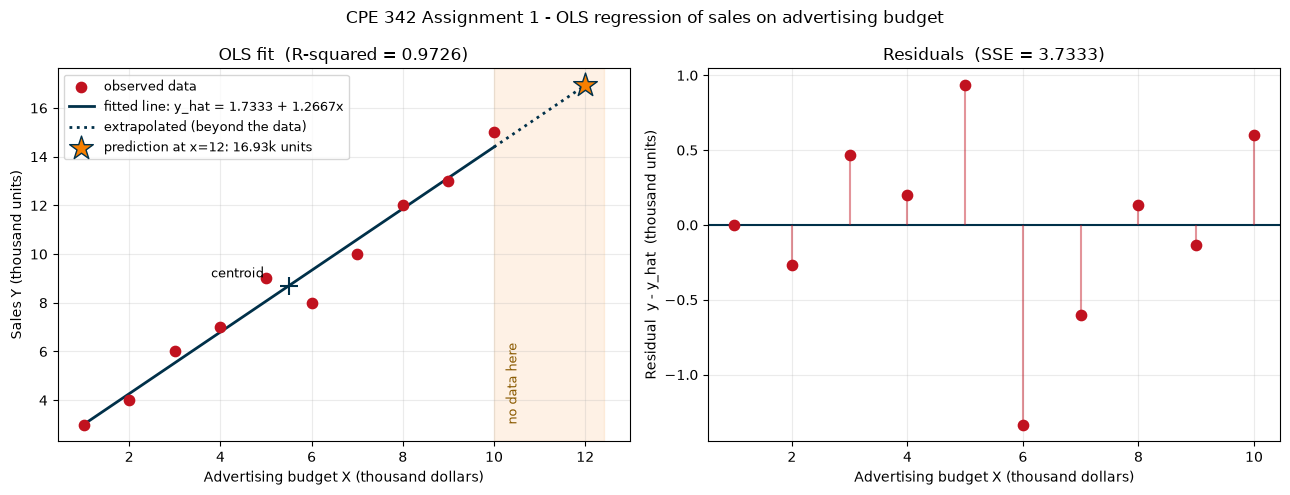

In [11]:
from pathlib import Path

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: data, fitted line, and the extrapolated prediction ---------------
line_x = np.linspace(x.min(), x.max(), 100)
extrap_x = np.linspace(x.max(), x_new, 50)

ax1.axvspan(x.max(), x_new + 0.4, color="#f77f00", alpha=0.10)
ax1.scatter(x, y, color="#c1121f", zorder=3, s=55, label="observed data")
ax1.plot(line_x, beta0 + beta1 * line_x, color="#003049", lw=2,
         label=f"fitted line: y_hat = {beta0:.4f} + {beta1:.4f}x")
ax1.plot(extrap_x, beta0 + beta1 * extrap_x, color="#003049", lw=2, ls=":",
         label="extrapolated (beyond the data)")
ax1.scatter([x_new], [y_pred], marker="*", s=320, color="#f77f00",
            edgecolor="#003049", zorder=4,
            label=f"prediction at x=12: {y_pred:.2f}k units")
ax1.text(x.max() + 0.25, y.min(), "no data here", fontsize=9, color="#8a5a00",
         rotation=90, va="bottom")
ax1.scatter([x_bar], [y_bar], marker="+", s=180, color="#003049", zorder=4)
ax1.annotate("centroid", (x_bar, y_bar), textcoords="offset points", xytext=(-56, 6), fontsize=9)

ax1.set_xlabel("Advertising budget X (thousand dollars)")
ax1.set_ylabel("Sales Y (thousand units)")
ax1.set_title(f"OLS fit  (R-squared = {r_squared:.4f})")
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(alpha=0.25)

# --- Right: residuals ------------------------------------------------------
ax2.axhline(0, color="#003049", lw=1.5)
ax2.vlines(x, 0, residuals, color="#c1121f", alpha=0.45, lw=1.5)
ax2.scatter(x, residuals, color="#c1121f", zorder=3, s=55)
ax2.set_xlabel("Advertising budget X (thousand dollars)")
ax2.set_ylabel("Residual  y - y_hat  (thousand units)")
ax2.set_title(f"Residuals  (SSE = {sse:.4f})")
ax2.grid(alpha=0.25)

fig.suptitle("CPE 342 Assignment 1 - OLS regression of sales on advertising budget", fontsize=12)
fig.tight_layout()

out = Path("figures")
out.mkdir(exist_ok=True)
fig.savefig(out / "fit_and_residuals.png", dpi=150, bbox_inches="tight")
print(f"figure saved to {out / 'fit_and_residuals.png'}")
plt.show()

### Your explanation - 3a - the R-squared calculation

> _Write your answer here._

<details>
<summary>Raw material (click to expand) - numbers and points you may want to cite</summary>

- SSE = 3.7333 and SST = 136.1000, so R^2 = 1 - 3.7333/136.1000 = 0.9726.
- SST is the squared error of always predicting y_bar = 8.7 thousand units; SSE is what the fitted line leaves behind.
- R^2 = 0.9726 means the model removes 97.26% of that baseline squared error.
- The residuals sum to zero - an automatic property of any OLS fit with an intercept, and a useful arithmetic check.
- Three independent routes agree: the hand calculation, the statsmodels R-squared, and the squared correlation r^2 (these coincide only in simple linear regression).

</details>

## 3b. Interpreting the R-squared value

The number is $R^2 = 0.9726$. A complete interpretation says three things: what it means, what
supports it, and what it does **not** mean.

- **What it means.** About 97.3% of the variation in monthly sales is accounted for by variation
  in the advertising budget; the remaining 2.7% is left to everything else - seasonality,
  competitors, pricing, and plain randomness.
- **What supports it.** The residual plot shows no curve and no fan shape, and the largest miss is
  small next to the spread of sales. A straight line looks like the right *shape* of model, not
  merely a high-scoring one.
- **What it does not mean.** It is not a measure of predictive accuracy on future months, it is
  not evidence that advertising *causes* sales, and it is computed from only 10 observations -
  which makes a high value easier to obtain by chance than it would be in a large sample.

In [12]:
# The size of a typical miss, which is what makes 0.9726 concrete.
rmse = np.sqrt(sse / n)

print(f"R^2 = {r_squared:.4f}  ({r_squared * 100:.2f}% of the variance in sales explained)")
print(f"unexplained: {(1 - r_squared) * 100:.2f}%")
print()
print(f"root mean squared residual = {rmse:.4f} thousand units (about {rmse * 1000:,.0f} units)")
print(f"mean sales                 = {y_bar:.4f} thousand units")
print(f"typical miss as a share of mean sales: {rmse / y_bar * 100:.2f}%")
print()
print(f"n = {n} observations - a small sample, so treat the high R^2 with appropriate caution")

R^2 = 0.9726  (97.26% of the variance in sales explained)
unexplained: 2.74%

root mean squared residual = 0.6110 thousand units (about 611 units)
mean sales                 = 8.7000 thousand units
typical miss as a share of mean sales: 7.02%

n = 10 observations - a small sample, so treat the high R^2 with appropriate caution


### Your explanation - 3b - interpreting R-squared

> _Write your answer here._

<details>
<summary>Raw material (click to expand) - numbers and points you may want to cite</summary>

- R^2 = 0.9726: about 97.3% of the variation in sales is explained by the advertising budget, leaving 2.7% unexplained.
- This is a very strong fit - the ten points lie close to the line, with a typical miss of about 0.61 thousand units (roughly 611 units, about 7% of mean sales).
- The residual plot shows no systematic pattern, which supports the choice of a straight line rather than a curve.
- Limits worth stating: R^2 measures fit to the data used for fitting; it is not predictive accuracy, and adding predictors can only increase it.
- Correlation is not causation - a high R^2 does not establish that advertising drives sales.
- With only n = 10 observations, a high R^2 is easier to achieve by chance than it would be in a large sample.

</details>

---

## Summary of results

Every number the assignment asked for, in one table.

In [13]:
summary = pd.DataFrame(
    [
        ["1b", "Intercept beta_0", f"{beta0:.4f}", "thousand units"],
        ["1b", "Slope beta_1", f"{beta1:.4f}", "thousand units per thousand dollars"],
        ["1c", "Fitted line", f"y_hat = {beta0:.4f} + {beta1:.4f} x", "x in k$, y_hat in k units"],
        ["2b", "Prediction at $12,000", f"{y_pred:.4f}",
         f"thousand units (about {y_pred * 1000:,.0f} units) - EXTRAPOLATION"],
        ["3a", "SSE", f"{sse:.4f}", "squared thousand units"],
        ["3a", "SST", f"{sst:.4f}", "squared thousand units"],
        ["3a", "R-squared", f"{r_squared:.4f}", f"{r_squared * 100:.2f}% of variance explained"],
    ],
    columns=["Task", "Quantity", "Value", "Unit / note"],
)
summary

,Task,Quantity,Value,Unit / note
0,1b,Intercept beta_0,1.7333,thousand units
1,1b,Slope beta_1,1.2667,thousand units per thousand dollars
2,1c,Fitted line,y_hat = 1.7333 + 1.2667 x,"x in k$, y_hat in k units"
3,2b,"Prediction at $12,000",16.9333,"thousand units (about 16,933 units) - EXTRAPOL..."
4,3a,SSE,3.7333,squared thousand units
5,3a,SST,136.1000,squared thousand units
6,3a,R-squared,0.9726,97.26% of variance explained


---

## Before submitting

- [ ] Fill in name, student ID, section and date in the cover table.
- [ ] Write every **Your explanation** slot - 1a, 1b, 1c, 2a, 2b, 3a, 3b. Those are the marks.
- [ ] Run `Restart Kernel and Run All Cells` once, and check that every output still appears.
- [ ] Confirm that each reported number carries a unit, and that the \$12,000 prediction is
      labelled as an extrapolation.
- [ ] Export to PDF and upload to LEB2.

**Reproducing the environment** (from the repository root):

```
py -3.14 -m venv .venv
.venv\Scripts\python.exe -m pip install -r requirements.txt
.venv\Scripts\python.exe -m ipykernel install --user --name cpe342 --display-name "CPE342 (.venv)"
```

Then select the **CPE342 (.venv)** kernel from the top right of this notebook.